<a href="https://colab.research.google.com/github/ayushmanpathak9034/Insurance-Claim-Prediction/blob/main/Insurance_Claim_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Insurance Claim Prediction - Logistic Regression Model
**Goal:** Predict `Claim_Status` using basic logistic regression with data cleaning and EDA.

# Problem Statement

Insurance companies need to predict whether a customer is likely to make a claim.
This helps them manage risk, detect fraud, and improve decision-making.

In this project, we build a Logistic Regression model to predict insurance claims
using an insurance dataset. The model learns patterns from customer details
such as age, BMI, smoking habits, and other factors to determine the probability
of a claim.

Objective:
To build a classification model using Logistic Regression that predicts
whether an insurance claim will occur based on input features.

In [91]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Data Preprocessing

Steps performed:

• Loaded the insurance dataset  
• Null Value Treatment (Mean / Median / Mode)  
• Converted categorical variables into numerical format  
• Outlier Detection & Removal using IQR Method  
• Visualizations  

### 1.  Load Dataset

In [92]:
# Load the insurance dataset
df = pd.read_csv('/content/insurance.csv')
print('Shape:', df.shape)
display(df.head())

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [93]:
# Basic info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [94]:
# Statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 2. Null Value Treatment (Mean / Median / Mode)

In [95]:
# Check null counts before treatment
print('Null values before treatment:')
print(df.isnull().sum())

Null values before treatment:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### 3. Label Encoding (Categorical → Numeric)

In [96]:
# Encode object columns using LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

Categorical columns: ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


### 4. Outlier Detection & Removal using IQR Method

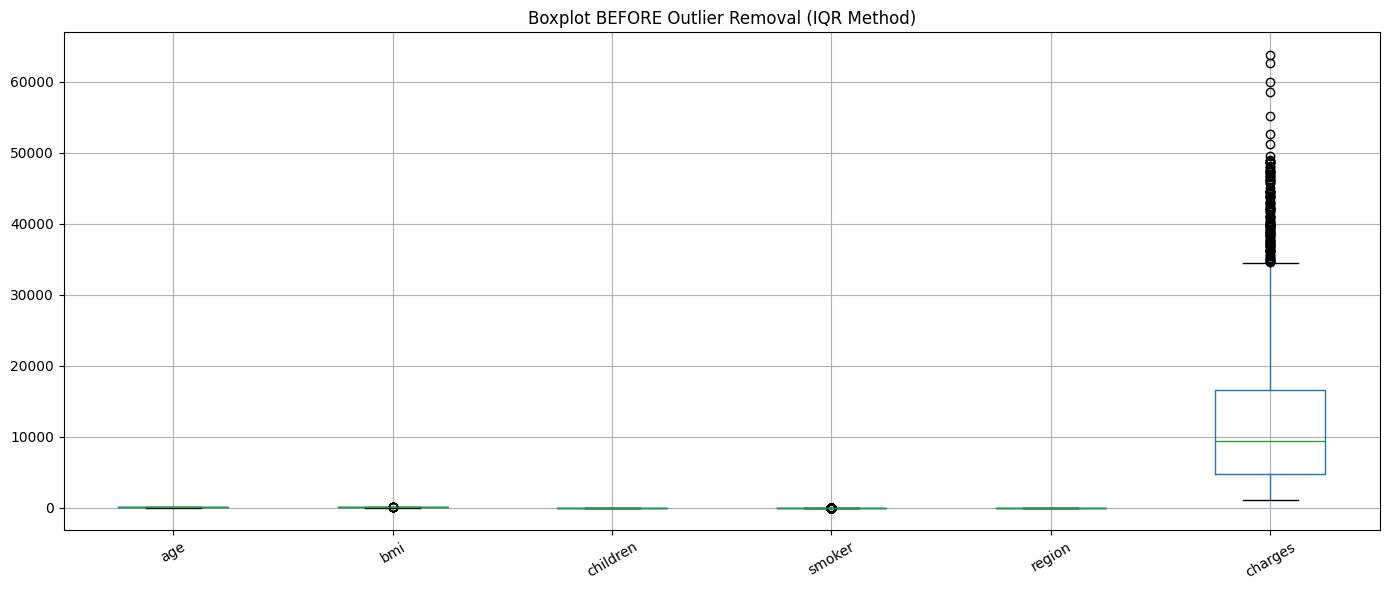

In [97]:
# Select numeric columns (excluding the target)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['sex']]

# ---- BEFORE Boxplot ----
plt.figure(figsize=(14, 6))
df[num_cols].boxplot(rot=30)
plt.title('Boxplot BEFORE Outlier Removal (IQR Method)')
plt.tight_layout()
plt.show()

In [98]:
# Create a binary target variable 'Claim_Status' for logistic regression
# We'll define a claim as 'high' (1) if charges are above the median, and 'low' (0) otherwise.
median_charges = insurance_df_cleaned['charges'].median()
insurance_df_cleaned['Claim_Status'] = (insurance_df_cleaned['charges'] > median_charges).astype(int)

print('Claim_Status distribution:')
print(insurance_df_cleaned['Claim_Status'].value_counts())
display(insurance_df_cleaned.head())

Claim_Status distribution:
Claim_Status
0    500
1    500
Name: count, dtype: int64


,age,sex,bmi,children,smoker,region,charges,Claim_Status
1,18,1,33.77,1,0,2,1725.5523,0
2,28,1,33.00,3,0,2,4449.4620,0
4,32,1,28.88,0,0,1,3866.8552,0
5,31,0,25.74,0,0,2,3756.6216,0
6,46,0,33.44,1,0,2,8240.5896,1


### 5. Visualizations

/tmp/ipykernel_13878/2049419971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Claim_Status', data=insurance_df_cleaned, palette='Set2')


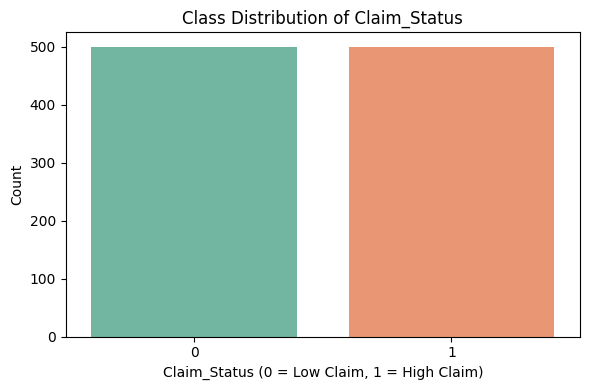

In [99]:
# --- Visualization 1: Target class distribution (Countplot) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Claim_Status', data=insurance_df_cleaned, palette='Set2')
plt.title('Class Distribution of Claim_Status')
plt.xlabel('Claim_Status (0 = Low Claim, 1 = High Claim)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Model Building

We used Logistic Regression to build a classification model
that predicts insurance claims.

Logistic Regression is suitable for classification problems
where the output is categorical.

### 6. Model Training - Logistic Regression

In [100]:
# Define features (X) and target (y)
# Exclude 'charges' as it was used to create 'Claim_Status' and is not a feature for prediction.
X_insurance = insurance_df_cleaned.drop(columns=['charges', 'Claim_Status'])
y_insurance = insurance_df_cleaned['Claim_Status']

# Split into train and test sets (80/20)
X_train_insurance, X_test_insurance, y_train_insurance, y_test_insurance = train_test_split(
    X_insurance, y_insurance, test_size=0.2, random_state=42, stratify=y_insurance
)

print('Train size:', X_train_insurance.shape)
print('Test size :', X_test_insurance.shape)

Train size: (800, 6)
Test size : (200, 6)


In [101]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_insurance, y_train_insurance)

LogisticRegression(max_iter=1000, random_state=42)

# Model Evaluation

The model performance was evaluated using:

• Accuracy Score  
• Confusion Matrix  

These metrics help determine how well the model predicts claims.

In [102]:
# Predictions on test set
y_pred = model.predict(X_test_insurance)

# Accuracy
acc = accuracy_score(y_test_insurance, y_pred)
print(f'Accuracy: {acc:.4f}')

Accuracy: 0.9450


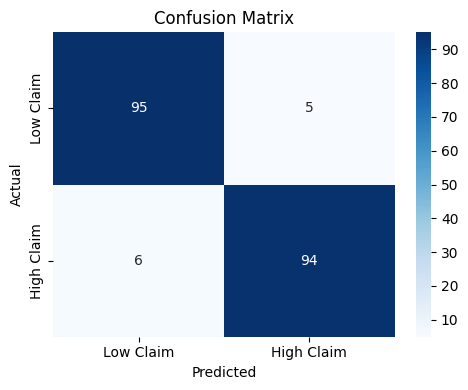

In [103]:
# Confusion Matrix heatmap
cm = confusion_matrix(y_test_insurance, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Claim', 'High Claim'],
            yticklabels=['Low Claim', 'High Claim'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()